In [56]:
import numpy as np
import cv2
from skimage.morphology import remove_small_objects, dilation, skeletonize, skeletonize_3d, medial_axis, binary_closing
from skimage.segmentation import clear_border
from skimage.filters import unsharp_mask, threshold_triangle, difference_of_gaussians
from skimage.graph import shortest_path, route_through_array
import matplotlib.pyplot as plt

In [57]:
#parameters

dmin = 1
dmax = 50

r = [256, 53, 290, 187]

num_of_segments = 3

In [58]:
depth_img = cv2.imread('/home/janch-ros/Documents/video_images/frame0070.jpg')

#70, 60, 53, 44, 34, 26, 14, 9, 7, 4, 1, 0

In [59]:
depth_img_cropped = depth_img[r[1]:r[1]+r[3], r[0]:r[0]+r[2]]
# depth_img[0:300, 0:300] = 0
# depth_img[0:80, 230:230+370] = 0
# depth_img[0:480, 550:550+300] = 0
# depth_img[240:240+240, 0:848] = 0

In [60]:
# cv2.imshow("Depth Window 1", depth_img_cropped)
# cv2.waitKey(5000)
cv2.imwrite('depth_cropped_1.jpg', depth_img_cropped)

True

In [61]:
depth_img_cropped = np.where((depth_img_cropped < dmin) | (depth_img_cropped > dmax), 0, depth_img_cropped)
# cv2.imshow("Depth Window 2", depth_img_cropped)
# cv2.waitKey(2000)
depth = depth_img_cropped
kernel = np.ones((8, 8), np.uint8)
# blur = cv2.GaussianBlur(depth_img_cropped, (5,5), 0)
depth = cv2.dilate(depth, kernel, iterations=1)
depth = cv2.erode(depth, kernel, iterations=3)
depth = cv2.morphologyEx(depth, cv2.MORPH_OPEN, kernel)

In [62]:
# cv2.imshow("Depth Window 3", depth)
# cv2.waitKey(5000)

cv2.imwrite('depth_gray_1.jpg', depth)

True

In [63]:
binary = np.where(depth > 0, 1, depth)
skeleton = skeletonize(binary)
# skeleton = np.array(skeleton, dtype=np.uint8)  
skeleton = cv2.cvtColor(skeleton, cv2.COLOR_BGR2GRAY)
skeleton = np.where(skeleton == 1, 255, skeleton)
print(skeleton.shape)
# skeleton = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)

(187, 290)


In [64]:
cv2.imwrite('depth_skel_1.jpg', skeleton)

True

In [65]:
pixels = np.argwhere(skeleton == 255)

pixels = np.flip(pixels)

copy_pix = pixels

print(copy_pix)

[[262 179]
 [261 179]
 [260 179]
 [259 179]
 [258 179]
 [257 179]
 [256 179]
 [255 179]
 [254 179]
 [253 178]
 [252 178]
 [251 177]
 [250 176]
 [249 176]
 [248 176]
 [247 175]
 [246 174]
 [245 173]
 [244 172]
 [243 171]
 [242 170]
 [242 169]
 [241 168]
 [241 167]
 [240 166]
 [239 165]
 [239 164]
 [238 163]
 [237 162]
 [236 161]
 [235 160]
 [234 159]
 [233 158]
 [232 157]
 [231 156]
 [230 155]
 [229 154]
 [228 153]
 [227 152]
 [226 151]
 [226 150]
 [226 149]
 [226 148]
 [226 147]
 [225 146]
 [225 145]
 [225 144]
 [225 143]
 [224 142]
 [223 141]
 [222 140]
 [222 139]
 [221 138]
 [221 137]
 [220 136]
 [220 135]
 [219 134]
 [ 75 134]
 [218 133]
 [ 75 133]
 [217 132]
 [ 76 132]
 [216 131]
 [ 76 131]
 [215 130]
 [ 76 130]
 [215 129]
 [ 76 129]
 [214 128]
 [ 76 128]
 [213 127]
 [ 77 127]
 [212 126]
 [ 78 126]
 [212 125]
 [ 79 125]
 [211 124]
 [210 124]
 [ 80 124]
 [209 123]
 [ 81 123]
 [208 122]
 [ 91 122]
 [ 90 122]
 [ 89 122]
 [ 88 122]
 [ 87 122]
 [ 86 122]
 [ 85 122]
 [ 84 122]
 [ 83 122]

In [66]:
initial_pos = pixels[0] #extract the center of the base marker and get initial position    
row_index, = np.where(np.all(copy_pix == [initial_pos], axis=1))
copy_pix = np.delete(copy_pix, row_index, axis=0)
print(copy_pix[0])
point_len = len(copy_pix)    
ordered = initial_pos
print(ordered)
# print(copy_pix[:,1])

[261 179]
[262 179]


In [67]:
while len(copy_pix)>0:
    distances = np.sqrt((copy_pix[:,0] - initial_pos[0]) ** 2 + (copy_pix[:,1] - initial_pos[1]) ** 2)
#     print(distances)
    nearest_index = np.argmin(distances)
    print("Point {} matched with {}".format(initial_pos, copy_pix[nearest_index]))
    print("Nearest index: {}".format(nearest_index))
    initial_pos = copy_pix[nearest_index] #(target[0], target[1])
    print("Initial Pose", initial_pos)
    copy_pix = np.delete(copy_pix, nearest_index, axis=0)
#     print(copy_pix[0])
    point_len = len(copy_pix)
    ordered = np.append(ordered, [initial_pos])
print(ordered)


Point [262 179] matched with [261 179]
Nearest index: 0
Initial Pose [261 179]
Point [261 179] matched with [260 179]
Nearest index: 0
Initial Pose [260 179]
Point [260 179] matched with [259 179]
Nearest index: 0
Initial Pose [259 179]
Point [259 179] matched with [258 179]
Nearest index: 0
Initial Pose [258 179]
Point [258 179] matched with [257 179]
Nearest index: 0
Initial Pose [257 179]
Point [257 179] matched with [256 179]
Nearest index: 0
Initial Pose [256 179]
Point [256 179] matched with [255 179]
Nearest index: 0
Initial Pose [255 179]
Point [255 179] matched with [254 179]
Nearest index: 0
Initial Pose [254 179]
Point [254 179] matched with [253 178]
Nearest index: 0
Initial Pose [253 178]
Point [253 178] matched with [252 178]
Nearest index: 0
Initial Pose [252 178]
Point [252 178] matched with [251 177]
Nearest index: 0
Initial Pose [251 177]
Point [251 177] matched with [250 176]
Nearest index: 0
Initial Pose [250 176]
Point [250 176] matched with [249 176]
Nearest index

In [68]:
ordered = np.reshape(ordered, (-1, 2))

x = ordered[:, 1]
y = ordered[:, 0]

print(ordered)


[[262 179]
 [261 179]
 [260 179]
 [259 179]
 [258 179]
 [257 179]
 [256 179]
 [255 179]
 [254 179]
 [253 178]
 [252 178]
 [251 177]
 [250 176]
 [249 176]
 [248 176]
 [247 175]
 [246 174]
 [245 173]
 [244 172]
 [243 171]
 [242 170]
 [242 169]
 [241 168]
 [241 167]
 [240 166]
 [239 165]
 [239 164]
 [238 163]
 [237 162]
 [236 161]
 [235 160]
 [234 159]
 [233 158]
 [232 157]
 [231 156]
 [230 155]
 [229 154]
 [228 153]
 [227 152]
 [226 151]
 [226 150]
 [226 149]
 [226 148]
 [226 147]
 [225 146]
 [225 145]
 [225 144]
 [225 143]
 [224 142]
 [223 141]
 [222 140]
 [222 139]
 [221 138]
 [221 137]
 [220 136]
 [220 135]
 [219 134]
 [218 133]
 [217 132]
 [216 131]
 [215 130]
 [215 129]
 [214 128]
 [213 127]
 [212 126]
 [212 125]
 [211 124]
 [210 124]
 [209 123]
 [208 122]
 [207 121]
 [207 120]
 [206 119]
 [206 118]
 [205 117]
 [204 116]
 [203 115]
 [202 114]
 [201 113]
 [200 113]
 [199 112]
 [198 112]
 [197 111]
 [196 110]
 [195 110]
 [194 109]
 [193 108]
 [192 107]
 [191 107]
 [190 107]
 [189 107]

/tmp/ipykernel_54702/3537223935.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


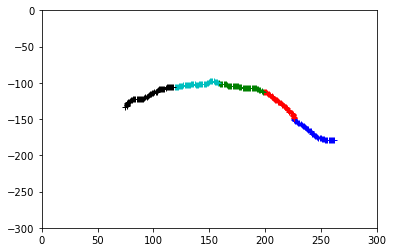

In [69]:
fig = None
if fig == None:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    fig.show()
    fig.canvas.draw()
ax.clear()
ax.set_xlim([0, 300])
ax.set_ylim([-300, 0])
# ax.set_ylim([0, 300])

ax.plot(y[0:41], -x[0:41], 'b+', label='Data')
ax.plot(y[41:81], -x[41:81], 'r+', label='Data')
ax.plot(y[81:121], -x[81:121], 'g+', label='Data')
ax.plot(y[121:161], -x[121:161], 'c+', label='Data')
ax.plot(y[161:-1], -x[161:-1], 'k+', label='Data')

In [70]:
points = ordered

new_img = np.zeros((300, 300, 3), dtype = "uint8")

for i in range(len(points)):
    x = np.int(points[i][0])
    y = np.int(points[i][1])
    cv2.circle(new_img,(x, y),0,(255,255,255),-1) 

cv2.imwrite('skel_branch_1.jpg', new_img)

True

In [71]:
xinit = points[:, 0]
yinit = points[:, 1]


In [72]:
point_jump = (len(xinit))/num_of_segments

print(point_jump)

70.33333333333333


In [73]:
x = np.array(xinit[0::round(point_jump)])
y = np.array(yinit[0::round(point_jump)])

In [74]:
print(x, y)

[262 207 139  75] [179 121 103 134]


In [75]:
if (x[-1] != xinit[-1]) or (y[-1] != yinit[-1]) :
    x = np.append(x, xinit[-1])
    y = np.append(y, yinit[-1])    
    print(x)
    print(y)
    if len(x) > num_of_segments + 1:
        x = np.delete(x, -2)
        y = np.delete(y, -2)

print(x, y)

[262 207 139  75] [179 121 103 134]


/tmp/ipykernel_54702/1591041879.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


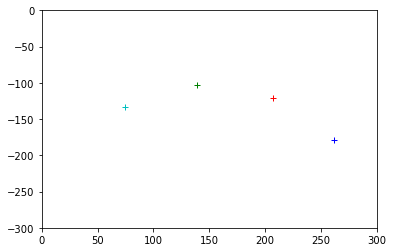

In [76]:
fig = None
if fig == None:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    fig.show()
    fig.canvas.draw()
ax.clear()
ax.set_xlim([0, 300])
# ax.set_ylim([0, 300])
ax.set_ylim([-300, 0])

ax.plot(x[0], -y[0], 'b+', label='Data')
ax.plot(x[1], -y[1], 'r+', label='Data')
ax.plot(x[2], -y[2], 'g+', label='Data')
ax.plot(x[3], -y[3], 'c+', label='Data')
# ax.plot(y[161:-1], -x[161:-1], 'k+', label='Data')

In [77]:
from scipy.interpolate import splprep, splev

tck, u_params = splprep([x, y], k = num_of_segments, s = 1)

In [78]:
cx = tck[1][0]
cy = tck[1][1]

cts = np.c_[cx, cy]

In [79]:
params = np.linspace(0, 1, 20)
# new points after evaluation
newPts =  np.array(splev(params, tck))
x = newPts[0]
y = newPts[1]
points = np.c_[x,y]

In [80]:
for i in range(len(cts)):
    x = np.int(cts[i][0])
    y = np.int(cts[i][1])
    cv2.circle(new_img,(x, y),5,(0,255,255),-1)

In [81]:
for i in range(len(points)):
    x = np.int(points[i][0])
    y = np.int(points[i][1])
    cv2.circle(new_img,(x, y),3,(255,0,0),-1)

In [82]:
cv2.imwrite('eval_points.jpg', new_img)

True